In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [33]:
data = pd.read_csv("../data/processed/walmart_processed.csv")

In [34]:
data.head() 

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Day,Quarter,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,2010,2,5,1,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,2010,2,12,1,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,2010,2,19,1,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,2010,2,26,1,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,2010,3,5,1,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315


In [35]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  str    
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Year          421570 non-null  int64  
 6   Month         421570 non-null  int64  
 7   Day           421570 non-null  int64  
 8   Quarter       421570 non-null  int64  
 9   Temperature   421570 non-null  float64
 10  Fuel_Price    421570 non-null  float64
 11  MarkDown1     421570 non-null  float64
 12  MarkDown2     421570 non-null  float64
 13  MarkDown3     421570 non-null  float64
 14  MarkDown4     421570 non-null  float64
 15  MarkDown5     421570 non-null  float64
 16  CPI           421570 non-null  float64
 17  Unemployment  421570 non-null  float64
 18  Type          4

In [36]:
data["Date"] = pd.to_datetime(data["Date"])

In [37]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Year          421570 non-null  int64         
 6   Month         421570 non-null  int64         
 7   Day           421570 non-null  int64         
 8   Quarter       421570 non-null  int64         
 9   Temperature   421570 non-null  float64       
 10  Fuel_Price    421570 non-null  float64       
 11  MarkDown1     421570 non-null  float64       
 12  MarkDown2     421570 non-null  float64       
 13  MarkDown3     421570 non-null  float64       
 14  MarkDown4     421570 non-null  float64       
 15  MarkDown5     421570 non-nul

In [38]:
data["Week"] = data["Date"].dt.isocalendar().week.astype(int)
data["DayOfWeek"] = data["Date"].dt.dayofweek
data["IsWeekend"] = data["DayOfWeek"] >= 5

In [39]:
data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Day,Quarter,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Week,DayOfWeek,IsWeekend
0,1,1,2010-02-05,24924.50,False,2010,2,5,1,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,5,4,False
1,1,1,2010-02-12,46039.49,True,2010,2,12,1,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,6,4,False
2,1,1,2010-02-19,41595.55,False,2010,2,19,1,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,7,4,False
3,1,1,2010-02-26,19403.54,False,2010,2,26,1,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,8,4,False
4,1,1,2010-03-05,21827.90,False,2010,3,5,1,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,9,4,False


In [40]:
data.dtypes

Store                    int64
Dept                     int64
Date            datetime64[us]
Weekly_Sales           float64
IsHoliday                 bool
Year                     int64
Month                    int64
Day                      int64
Quarter                  int64
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
Type                       str
Size                     int64
Week                     int64
DayOfWeek                int32
IsWeekend                 bool
dtype: object

In [41]:
numeric_data = data.select_dtypes(include=["number"])

In [42]:
numeric_data.corr().round(2)

,Store,Dept,Weekly_Sales,Year,Month,Day,Quarter,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,Week,DayOfWeek
Store,1.00,0.02,-0.09,0.00,0.00,-0.00,0.00,-0.05,0.07,-0.06,-0.03,-0.02,-0.04,-0.01,-0.21,0.21,-0.18,0.00,NaN
Dept,0.02,1.00,0.15,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.01,0.01,-0.00,0.00,NaN
Weekly_Sales,-0.09,0.15,1.00,-0.01,0.03,-0.01,0.02,-0.00,-0.00,0.05,0.02,0.04,0.04,0.05,-0.02,-0.03,0.24,0.03,NaN
Year,0.00,0.00,-0.01,1.00,-0.19,0.01,-0.18,0.07,0.78,0.50,0.13,0.01,0.34,0.40,0.07,-0.24,-0.00,-0.18,NaN
Month,0.00,0.00,0.03,-0.19,1.00,0.02,0.97,0.24,-0.04,-0.09,-0.02,0.12,-0.11,0.06,0.01,-0.01,-0.00,1.00,NaN
Day,-0.00,-0.00,-0.01,0.01,0.02,1.00,0.02,0.03,0.03,-0.13,0.05,0.07,-0.15,-0.06,0.00,-0.00,-0.00,0.10,NaN
Quarter,0.00,0.00,0.02,-0.18,0.97,0.02,1.00,0.24,-0.04,-0.11,-0.02,0.11,-0.11,0.04,0.01,-0.02,-0.00,0.96,NaN
Temperature,-0.05,0.00,-0.00,0.07,0.24,0.03,0.24,1.00,0.14,-0.03,-0.18,-0.06,-0.05,-0.01,0.18,0.10,-0.06,0.24,NaN
Fuel_Price,0.07,0.00,-0.00,0.78,-0.04,0.03,-0.04,0.14,1.00,0.30,0.03,0.02,0.17,0.22,-0.16,-0.03,0.00,-0.03,NaN
MarkDown1,-0.06,0.00,0.05,0.50,-0.09,-0.13,-0.11,-0.03,0.30,1.00,0.17,-0.01,0.84,0.42,0.01,-0.11,0.17,-0.09,NaN


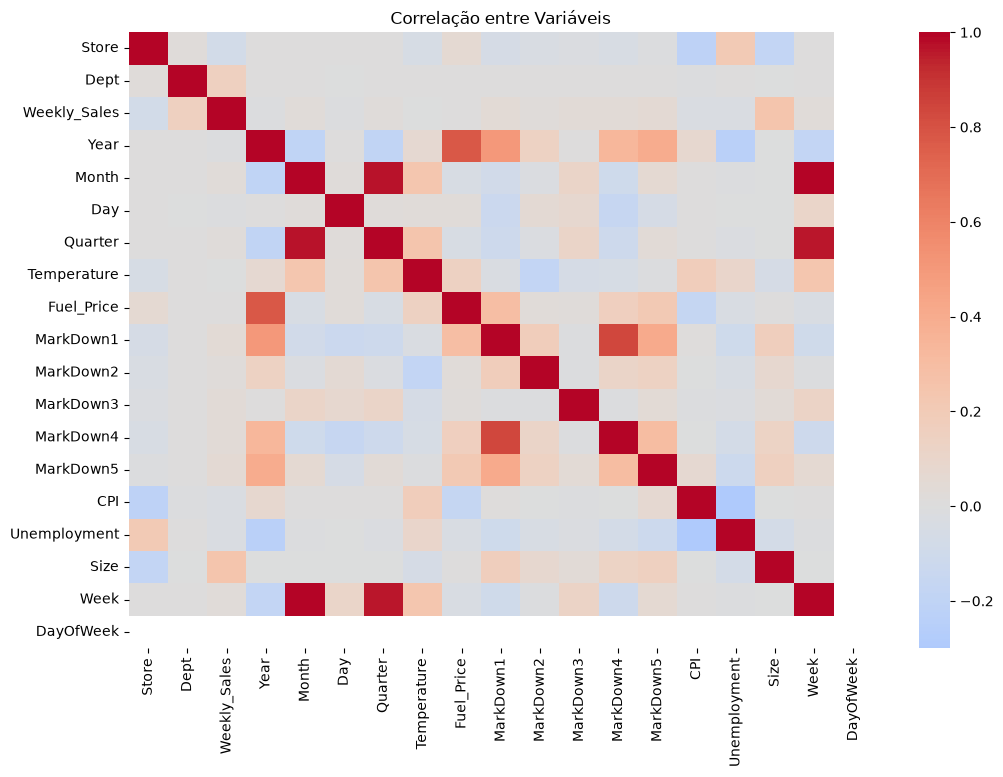

In [43]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_data.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlação entre Variáveis")
plt.show()

In [44]:
numeric_data.corr()["Weekly_Sales"].sort_values(ascending=False)

Weekly_Sales    1.000000
Size            0.243828
Dept            0.148032
MarkDown5       0.050465
MarkDown1       0.047172
MarkDown3       0.038562
MarkDown4       0.037467
Month           0.028409
Week            0.027673
Quarter         0.023838
MarkDown2       0.020716
Fuel_Price     -0.000120
Temperature    -0.002312
Day            -0.006187
Year           -0.010111
CPI            -0.020921
Unemployment   -0.025864
Store          -0.085195
DayOfWeek            NaN
Name: Weekly_Sales, dtype: float64

In [45]:
data = pd.get_dummies(
    data,
    columns=["Type"],
    drop_first=True
)

data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Day,Quarter,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,Week,DayOfWeek,IsWeekend,Type_B,Type_C
0,1,1,2010-02-05,24924.50,False,2010,2,5,1,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,151315,5,4,False,False,False
1,1,1,2010-02-12,46039.49,True,2010,2,12,1,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,151315,6,4,False,False,False
2,1,1,2010-02-19,41595.55,False,2010,2,19,1,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,151315,7,4,False,False,False
3,1,1,2010-02-26,19403.54,False,2010,2,26,1,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,151315,8,4,False,False,False
4,1,1,2010-03-05,21827.90,False,2010,3,5,1,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,151315,9,4,False,False,False


In [46]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 24 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Year          421570 non-null  int64         
 6   Month         421570 non-null  int64         
 7   Day           421570 non-null  int64         
 8   Quarter       421570 non-null  int64         
 9   Temperature   421570 non-null  float64       
 10  Fuel_Price    421570 non-null  float64       
 11  MarkDown1     421570 non-null  float64       
 12  MarkDown2     421570 non-null  float64       
 13  MarkDown3     421570 non-null  float64       
 14  MarkDown4     421570 non-null  float64       
 15  MarkDown5     421570 non-nul

In [47]:
X = data.drop(
    columns=[
        "Weekly_Sales",
        "Date"
    ]
)

y = data["Weekly_Sales"]

In [48]:
print(X.shape)
print(y.shape)

(421570, 22)
(421570,)


In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [50]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(337256, 22)
(84314, 22)
(337256,)
(84314,)


In [51]:
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [52]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](22,)","[-141.8 , 110.18, 180.26,..., 0. ,-402.12,5856.02]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](22,)","['Store','Dept','IsHoliday',...,'IsWeekend','Type_B','Type_C']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.066e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,22
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(19)


In [53]:
y_pred = linear_model.predict(X_test)

In [54]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 14561.50
RMSE: 21753.61
R²  : 0.0925


In [55]:
comparison = pd.DataFrame({
    "Real": y_test.values,
    "Previsto": y_pred
})

comparison.head(10)

,Real,Previsto
0,50932.42,19489.658819
1,3196.12,19856.789068
2,10125.03,4749.741903
3,3311.26,9214.053704
4,6335.65,26617.888503
5,8971.23,26298.138022
6,1575.35,11037.826164
7,17308.45,17989.178600
8,5763.39,21916.574007
9,17034.57,20956.484190


In [56]:
from sklearn.ensemble import RandomForestRegressor

In [57]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_l

In [58]:
y_pred_rf = rf.predict(X_test)

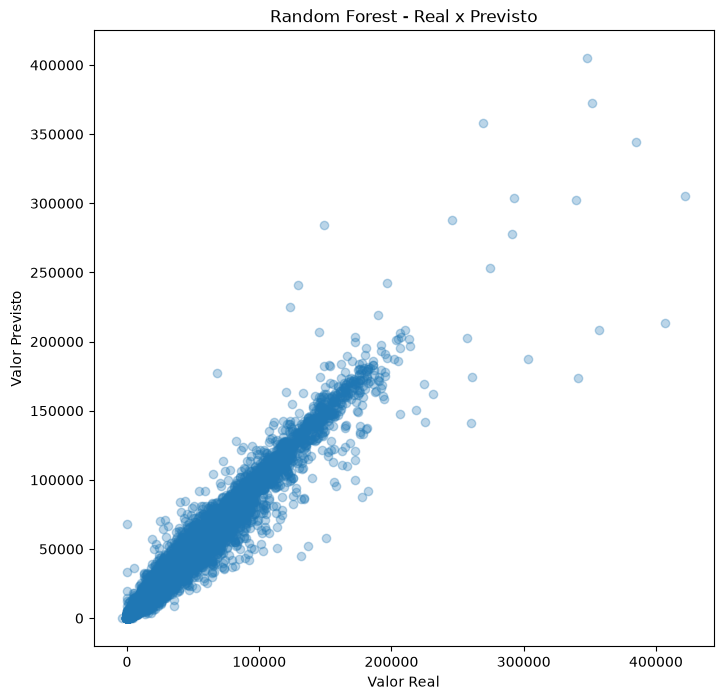

In [59]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.3
)

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Random Forest - Real x Previsto")

plt.savefig(
    "../images/random_forest_real_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [60]:
importance = pd.DataFrame({
    "Variável": X.columns,
    "Coeficiente": linear_model.coef_
})

importance = importance.sort_values(
    by="Coeficiente",
    key=abs,
    ascending=False
)

importance.head(15)

,Variável,Coeficiente
21,Type_C,5856.020339
6,Quarter,-1208.104523
3,Year,-1025.326525
8,Fuel_Price,798.299513
20,Type_B,-402.123668
15,Unemployment,-281.353806
2,IsHoliday,180.263614
0,Store,-141.798608
1,Dept,110.177121
4,Month,101.550223


In [61]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE : {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R²  : {r2_rf:.4f}")

MAE : 1396.91
RMSE: 3525.47
R²  : 0.9762


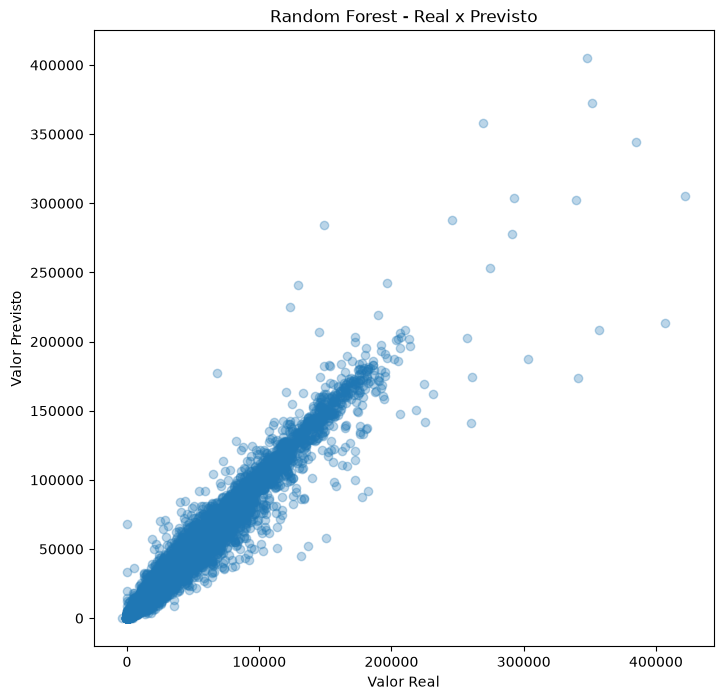

In [62]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.3
)

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Random Forest - Real x Previsto")

plt.show()

In [63]:
importance_rf = pd.DataFrame({
    "Variável": X.columns,
    "Importância": rf.feature_importances_
})

importance_rf = importance_rf.sort_values(
    "Importância",
    ascending=False
)

importance_rf.head(15)

,Variável,Importância
1,Dept,0.630687
16,Size,0.192003
0,Store,0.057228
17,Week,0.037206
14,CPI,0.025492
20,Type_B,0.011656
15,Unemployment,0.010673
7,Temperature,0.008249
5,Day,0.007341
4,Month,0.006484


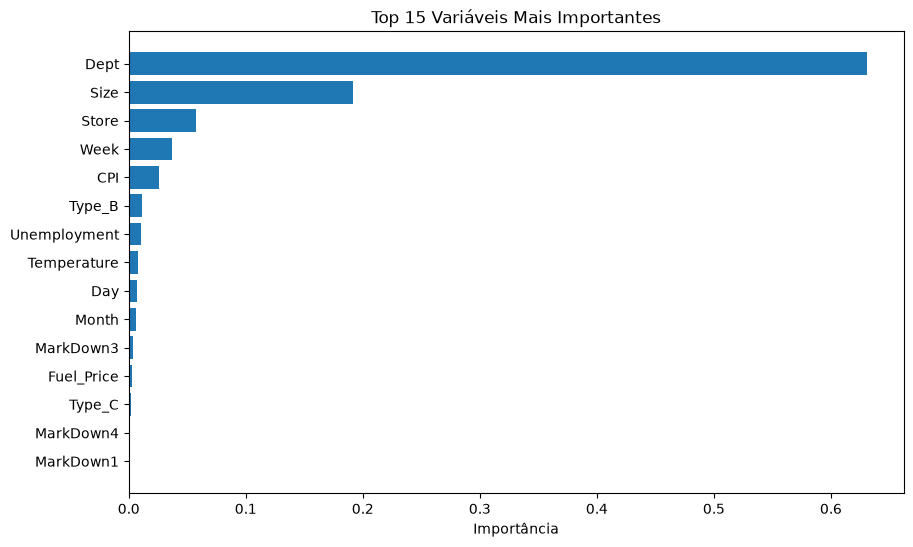

In [64]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance_rf["Variável"][:15],
    importance_rf["Importância"][:15]
)

plt.xlabel("Importância")
plt.title("Top 15 Variáveis Mais Importantes")

plt.gca().invert_yaxis()

plt.savefig(
    "../images/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [68]:
import joblib

joblib.dump(
    rf,
    "../data/processed/random_forest_model.pkl",
    compress=3
)

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


In [66]:
joblib.dump(X.columns.tolist(),
            "../data/processed/model_columns.pkl")

print("Colunas salvas!")

Colunas salvas!


In [67]:
import os

os.listdir("../data/processed")

['model_columns.pkl', 'random_forest_model.pkl', 'walmart_processed.csv']